# 🗑️ Image Classification: Deteksi Jenis Sampah
## Menggunakan Convolutional Neural Network (CNN)

 *BROIGES HASIAN HASIBUAN*
 
 *NIM: 4222301086*
 
**Dataset:** `TrashType_Image_Dataset`  
**Alur CNN:** `Input → Conv → ReLU → Pool → Flatten → FC → Softmax → Output`

| Komponen | Detail |
|----------|--------|
| Framework | TensorFlow / Keras |
| Input Size | 128 × 128 × 3 |
| Arsitektur | 3× Conv-BN-Pool + 2× FC |
| Optimizer | Adam |
| Loss | Categorical Cross-Entropy |


## 1. Import Library

In [50]:
import sys
print(sys.executable)

c:\ProgramData\anaconda3\python.exe


In [51]:
import sys
!{sys.executable} -m pip install tensorflow

Defaulting to user installation because normal site-packages is not writeable


In [52]:
import sys
print(sys.version)

3.13.9 | packaged by Anaconda, Inc. | (main, Oct 21 2025, 19:09:58) [MSC v.1929 64 bit (AMD64)]


In [53]:
import os, random, warnings
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
warnings.filterwarnings('ignore')

import tensorflow as tf
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import (Conv2D, MaxPooling2D, Flatten,
                                     Dense, Dropout, BatchNormalization)
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.utils import plot_model
from sklearn.metrics import classification_report, confusion_matrix
from PIL import Image

print(f"TensorFlow : {tf.__version__}")
print(f"GPU        : {tf.config.list_physical_devices('GPU')}")


TensorFlow : 2.21.0
GPU        : []


## 2. Load Dataset — Auto-Detect Struktur Folder

In [35]:
# ── Ganti sesuai lokasi dataset kamu ─────────────────────────────────────
DATASET_DIR = "TrashType_Image_Dataset"   # <── EDIT INI jika perlu

# ── Auto-detect apakah ada subfolder train/test atau langsung kelas ───────
def find_class_dirs(base):
    """Return (train_dir, test_dir, has_split)."""
    entries = [e for e in os.listdir(base)
               if os.path.isdir(os.path.join(base, e))]

    # Cek apakah ada subfolder bernama train/test/val
    lower = [e.lower() for e in entries]
    train_candidates = [entries[i] for i, e in enumerate(lower)
                        if e in ('train','training')]
    test_candidates  = [entries[i] for i, e in enumerate(lower)
                        if e in ('test','testing','val','valid','validation')]

    if train_candidates:
        train_dir = os.path.join(base, train_candidates[0])
        test_dir  = os.path.join(base, test_candidates[0]) if test_candidates else train_dir
        return train_dir, test_dir, True
    else:
        # Dataset langsung berisi folder kelas — pakai semuanya sebagai train
        return base, base, False

TRAIN_DIR, TEST_DIR, HAS_SPLIT = find_class_dirs(DATASET_DIR)

CLASSES    = sorted([d for d in os.listdir(TRAIN_DIR)
                     if os.path.isdir(os.path.join(TRAIN_DIR, d))])
NUM_CLASSES = len(CLASSES)

# ── Ringkasan ─────────────────────────────────────────────────────────────
print(f"Dataset dir : {DATASET_DIR}")
print(f"Train dir   : {TRAIN_DIR}")
print(f"Test dir    : {TEST_DIR}")
print(f"Split       : {'Train/Test terpisah' if HAS_SPLIT else 'Tidak ada split — pakai validation_split'}")
print(f"Kelas ({NUM_CLASSES})  : {CLASSES}")
print()

total = 0
for cls in CLASSES:
    n = len(os.listdir(os.path.join(TRAIN_DIR, cls)))
    total += n
    print(f"  {cls:<15} : {n} gambar")
print(f"  {'TOTAL':<15} : {total} gambar")


Dataset dir : TrashType_Image_Dataset
Train dir   : TrashType_Image_Dataset
Test dir    : TrashType_Image_Dataset
Split       : Tidak ada split — pakai validation_split
Kelas (6)  : ['cardboard', 'glass', 'metal', 'paper', 'plastic', 'trash']

  cardboard       : 403 gambar
  glass           : 501 gambar
  metal           : 410 gambar
  paper           : 594 gambar
  plastic         : 482 gambar
  trash           : 137 gambar
  TOTAL           : 2527 gambar


## 3. Visualisasi Sampel Gambar per Kelas

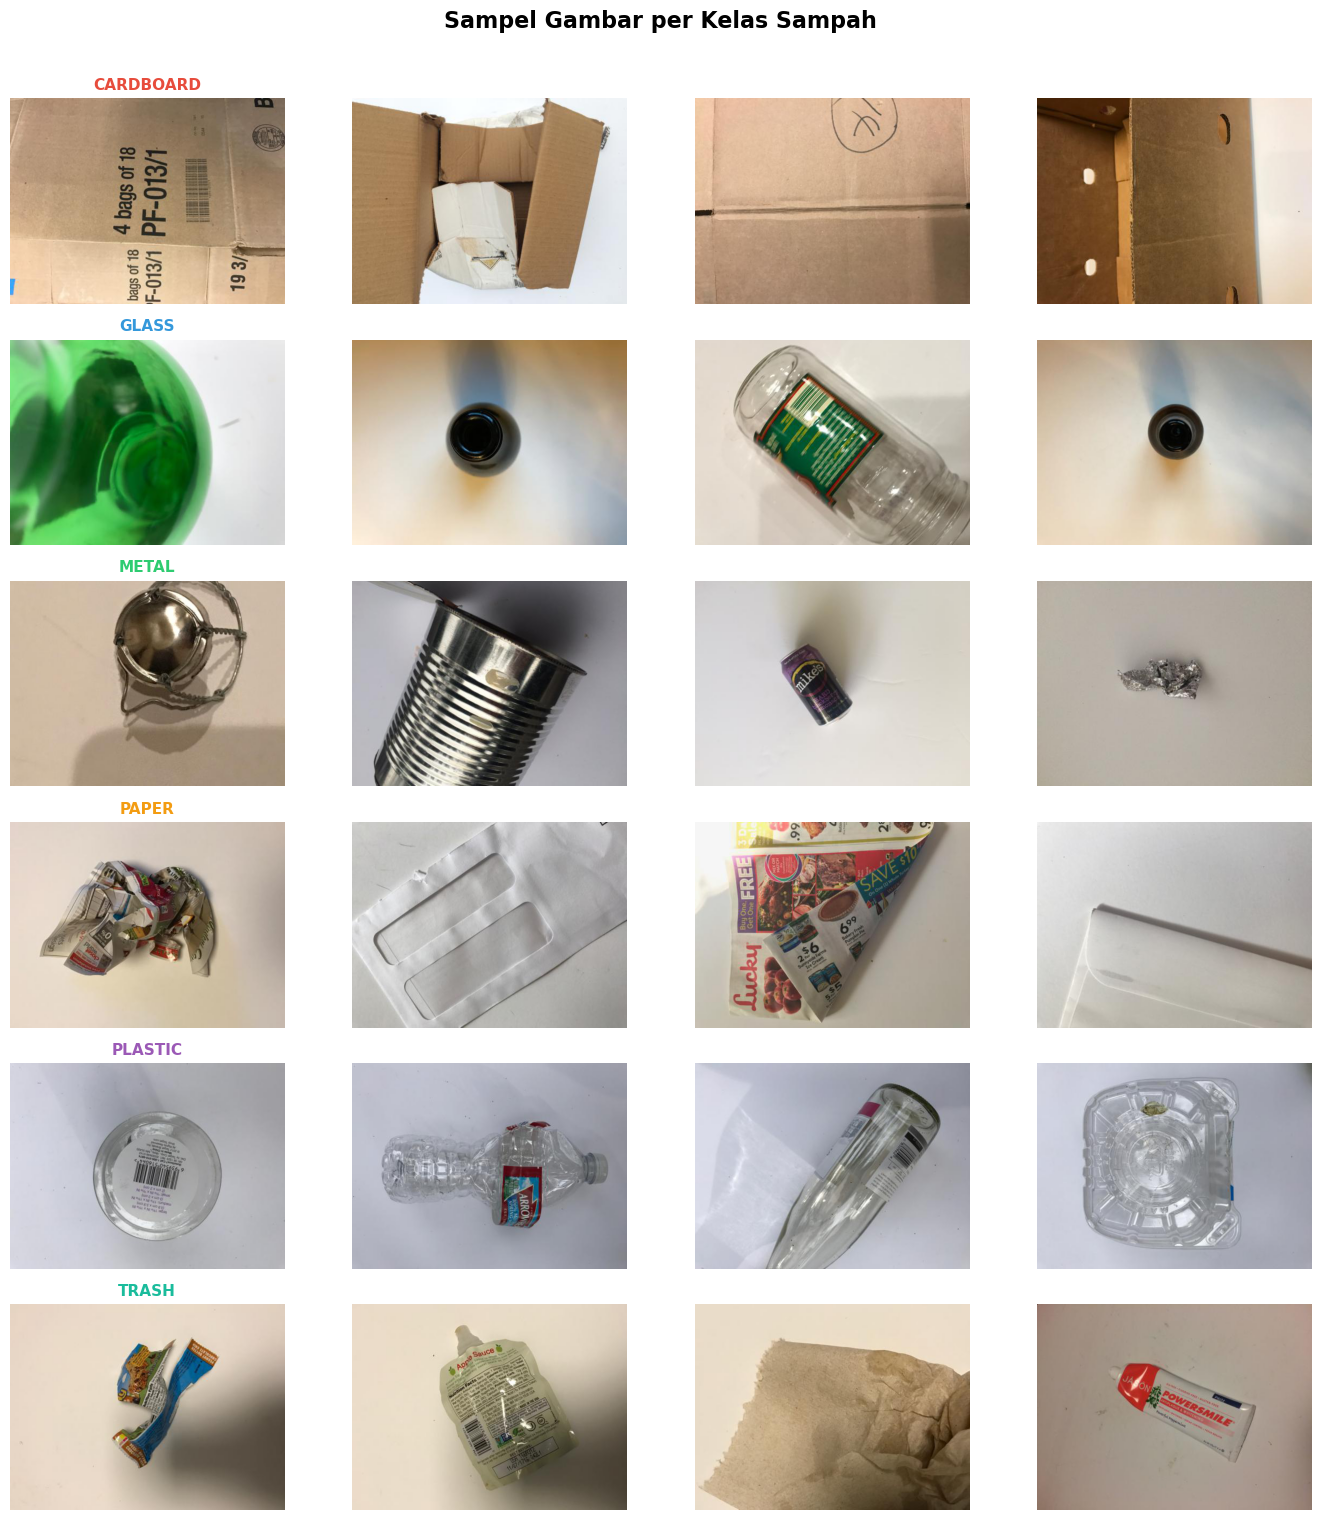

✅ Disimpan: sample_images.png


In [54]:
CLASS_COLORS = ['#e74c3c','#3498db','#2ecc71','#f39c12','#9b59b6','#1abc9c',
                '#e67e22','#16a085','#8e44ad','#2980b9']

fig, axes = plt.subplots(NUM_CLASSES, 4, figsize=(14, NUM_CLASSES * 2.5))
if NUM_CLASSES == 1:
    axes = axes[np.newaxis, :]
fig.suptitle("Sampel Gambar per Kelas Sampah", fontsize=16, fontweight='bold', y=1.01)

for row, cls in enumerate(CLASSES):
    cls_dir = os.path.join(TRAIN_DIR, cls)
    all_imgs = [f for f in os.listdir(cls_dir)
                if f.lower().endswith(('.jpg','.jpeg','.png','.webp'))]
    chosen = random.sample(all_imgs, min(4, len(all_imgs)))

    for col in range(4):
        ax = axes[row, col]
        if col < len(chosen):
            img = Image.open(os.path.join(cls_dir, chosen[col])).convert("RGB")
            ax.imshow(img)
        ax.axis('off')
        if col == 0:
            ax.set_title(cls.upper(), fontsize=11, fontweight='bold',
                         color=CLASS_COLORS[row % len(CLASS_COLORS)])

plt.tight_layout()
plt.savefig("sample_images.png", dpi=100, bbox_inches='tight')
plt.show()
print("✅ Disimpan: sample_images.png")


## 4. Distribusi Jumlah Gambar per Kelas

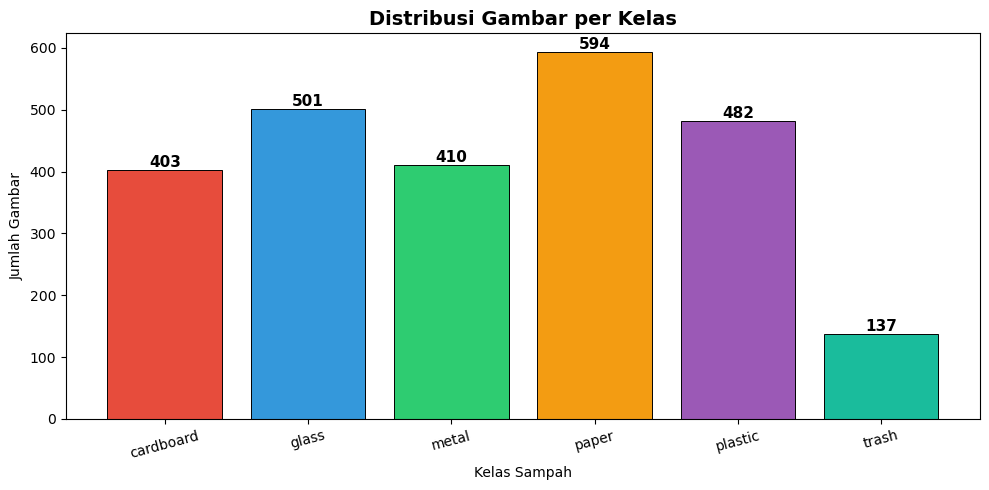

Total gambar: 2527


In [55]:
counts = {}
for cls in CLASSES:
    cls_dir = os.path.join(TRAIN_DIR, cls)
    counts[cls] = len([f for f in os.listdir(cls_dir)
                       if f.lower().endswith(('.jpg','.jpeg','.png','.webp'))])

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(counts.keys(), counts.values(),
              color=CLASS_COLORS[:NUM_CLASSES], edgecolor='black', linewidth=0.7)
ax.set_title("Distribusi Gambar per Kelas", fontsize=14, fontweight='bold')
ax.set_xlabel("Kelas Sampah"); ax.set_ylabel("Jumlah Gambar")
ax.tick_params(axis='x', rotation=15)

for bar, (k, v) in zip(bars, counts.items()):
    ax.text(bar.get_x() + bar.get_width()/2, v + 5, str(v),
            ha='center', fontweight='bold', fontsize=11)

plt.tight_layout()
plt.savefig("distribusi_kelas.png", dpi=100, bbox_inches='tight')
plt.show()
print(f"Total gambar: {sum(counts.values())}")


## 5. Preprocessing & Data Augmentation

Teknik augmentasi yang dipakai:
- **Rescale** → normalisasi piksel `[0–255]` → `[0–1]`
- **Rotation** → rotasi acak ±20°
- **Zoom** → zoom in/out 20%
- **Horizontal Flip** → cermin horizontal
- **Shift** → geser horizontal & vertikal 10%


In [56]:
IMG_SIZE   = (128, 128)
BATCH_SIZE = 32

# ── ImageDataGenerator ────────────────────────────────────────────────────
train_datagen = ImageDataGenerator(
    rescale            = 1./255,
    rotation_range     = 20,
    zoom_range         = 0.2,
    horizontal_flip    = True,
    width_shift_range  = 0.1,
    height_shift_range = 0.1,
    validation_split   = 0.2
)

test_datagen = ImageDataGenerator(rescale=1./255)

# ── Load Data ─────────────────────────────────────────────────────────────
train_data = train_datagen.flow_from_directory(
    TRAIN_DIR,
    target_size    = IMG_SIZE,
    batch_size     = BATCH_SIZE,
    class_mode     = 'categorical',
    subset         = 'training',
    shuffle        = True,
    seed           = 42
)

val_data = train_datagen.flow_from_directory(
    TRAIN_DIR,
    target_size    = IMG_SIZE,
    batch_size     = BATCH_SIZE,
    class_mode     = 'categorical',
    subset         = 'validation',
    shuffle        = False,
    seed           = 42
)

# Test — pakai TEST_DIR jika berbeda, jika tidak pakai val_data
if HAS_SPLIT and TEST_DIR != TRAIN_DIR:
    test_data = test_datagen.flow_from_directory(
        TEST_DIR,
        target_size = IMG_SIZE,
        batch_size  = BATCH_SIZE,
        class_mode  = 'categorical',
        shuffle     = False
    )
else:
    test_data = val_data
    print("ℹ️  Tidak ada test split terpisah — menggunakan validation set sebagai test.")

CLASS_NAMES = list(train_data.class_indices.keys())
print(f"\nClass mapping: {train_data.class_indices}")
print(f"Train   : {train_data.samples} gambar")
print(f"Val     : {val_data.samples} gambar")
print(f"Test    : {test_data.samples} gambar")


Found 2024 images belonging to 6 classes.
Found 503 images belonging to 6 classes.
ℹ️  Tidak ada test split terpisah — menggunakan validation set sebagai test.

Class mapping: {'cardboard': 0, 'glass': 1, 'metal': 2, 'paper': 3, 'plastic': 4, 'trash': 5}
Train   : 2024 gambar
Val     : 503 gambar
Test    : 503 gambar


## 6. Visualisasi Efek Data Augmentasi

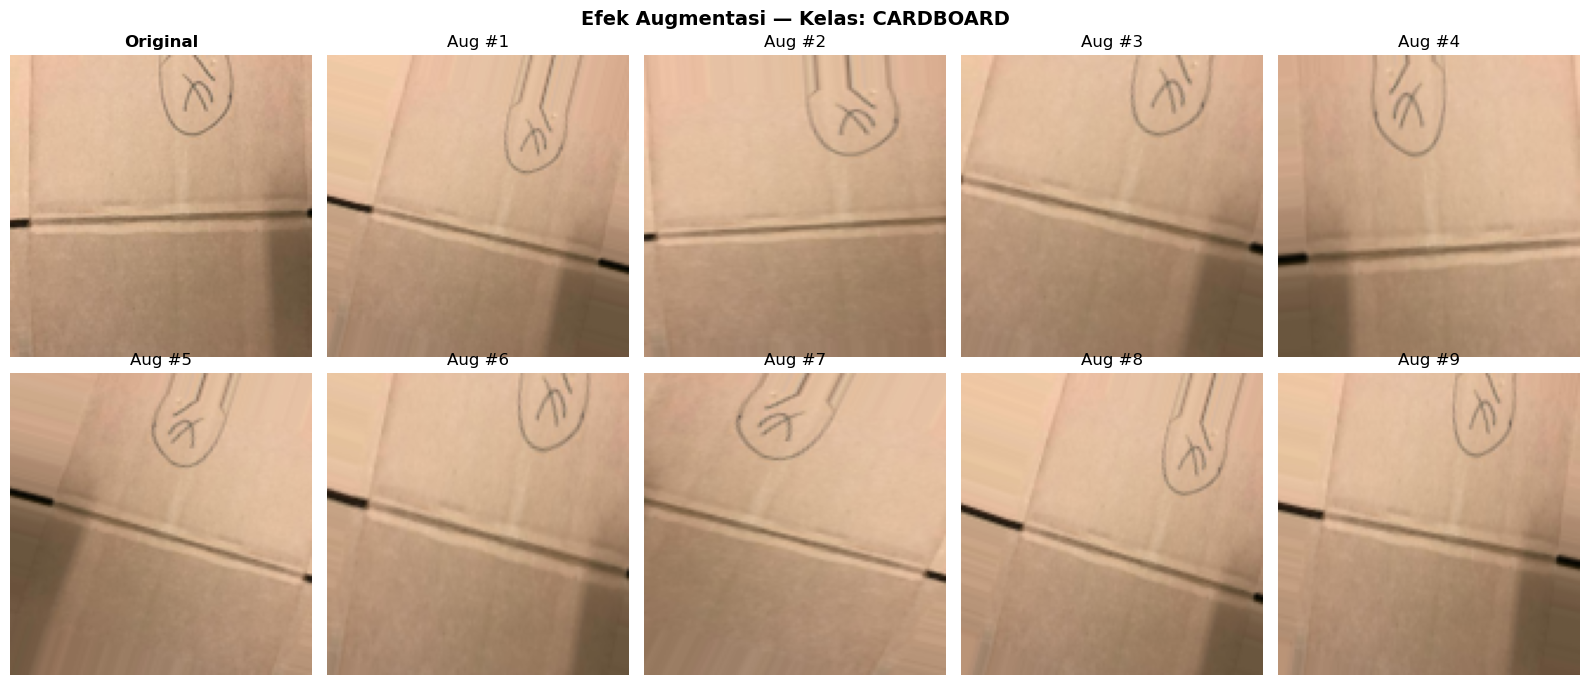

✅ Disimpan: augmentasi.png


In [57]:
# Pilih satu gambar dari kelas pertama
sample_cls = CLASSES[0]
sample_dir = os.path.join(TRAIN_DIR, sample_cls)
sample_files = [f for f in os.listdir(sample_dir)
                if f.lower().endswith(('.jpg','.jpeg','.png'))]
sample_path = os.path.join(sample_dir, sample_files[0])

orig = np.array(Image.open(sample_path).resize(IMG_SIZE)) / 255.0

aug_gen = ImageDataGenerator(
    rotation_range=20, zoom_range=0.2,
    horizontal_flip=True, width_shift_range=0.1, height_shift_range=0.1
)
aug_iter = aug_gen.flow(orig[np.newaxis], batch_size=1)

fig, axes = plt.subplots(2, 5, figsize=(16, 7))
fig.suptitle(f"Efek Augmentasi — Kelas: {sample_cls.upper()}", fontsize=14, fontweight='bold')

axes[0,0].imshow(orig); axes[0,0].set_title("Original", fontweight='bold'); axes[0,0].axis('off')
for i in range(1, 10):
    r, c = divmod(i, 5)
    aug = next(aug_iter)[0]
    axes[r,c].imshow(np.clip(aug, 0, 1))
    axes[r,c].set_title(f"Aug #{i}"); axes[r,c].axis('off')

plt.tight_layout()
plt.savefig("augmentasi.png", dpi=100, bbox_inches='tight')
plt.show()
print("✅ Disimpan: augmentasi.png")


## 7. Arsitektur CNN

```
Input (128×128×3)
  └─ Conv2D(32) + ReLU + BN → MaxPool    ← deteksi tepi & garis
  └─ Conv2D(64) + ReLU + BN → MaxPool    ← deteksi bentuk & pola
  └─ Conv2D(128)+ ReLU + BN → MaxPool    ← deteksi fitur kompleks
  └─ Flatten
  └─ Dense(256) + ReLU + Dropout(0.5)
  └─ Dense(128) + ReLU
  └─ Dense(N_kelas) + Softmax → Output
```


In [58]:
model = Sequential([
    # Block 1
    Conv2D(32, (3,3), activation='relu', padding='same',
           input_shape=(128, 128, 3), name='Conv1'),
    BatchNormalization(name='BN1'),
    MaxPooling2D((2,2), name='Pool1'),

    # Block 2
    Conv2D(64, (3,3), activation='relu', padding='same', name='Conv2'),
    BatchNormalization(name='BN2'),
    MaxPooling2D((2,2), name='Pool2'),
    Dropout(0.25, name='Drop1'),

    # Block 3
    Conv2D(128, (3,3), activation='relu', padding='same', name='Conv3'),
    BatchNormalization(name='BN3'),
    MaxPooling2D((2,2), name='Pool3'),
    Dropout(0.25, name='Drop2'),

    # FC
    Flatten(name='Flatten'),
    Dense(256, activation='relu', name='FC1'),
    BatchNormalization(name='BN4'),
    Dropout(0.5, name='Drop3'),
    Dense(128, activation='relu', name='FC2'),
    Dense(NUM_CLASSES, activation='softmax', name='Output')
], name="CNN_TrashDetection")

model.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])

model.summary()


Model: "CNN_TrashDetection"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ Conv1 (Conv2D)                  │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ BN1 (BatchNormalization)        │ (None, 128, 128, 32)   │           128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Pool1 (MaxPooling2D)            │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Conv2 (Conv2D)                  │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ BN2 (BatchNormalization)        │ (None, 64, 64, 64)     │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Pool2 (MaxPooling2D)            │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Drop1 (Dropout)                 │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Conv3 (Conv2D)                  │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ BN3 (BatchNormalization)        │ (None, 32, 32, 128)    │           512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Pool3 (MaxPooling2D)            │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Drop2 (Dropout)                 │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Flatten (Flatten)               │ (None, 32768)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ FC1 (Dense)                     │ (None, 256)            │     8,388,864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ BN4 (BatchNormalization)        │ (None, 256)            │         1,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Drop3 (Dropout)                 │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ FC2 (Dense)                     │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Output (Dense)                  │ (None, 6)              │           774 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 8,517,702 (32.49 MB)

 Trainable params: 8,516,742 (32.49 MB)

 Non-trainable params: 960 (3.75 KB)

## 8. Visualisasi Arsitektur Model

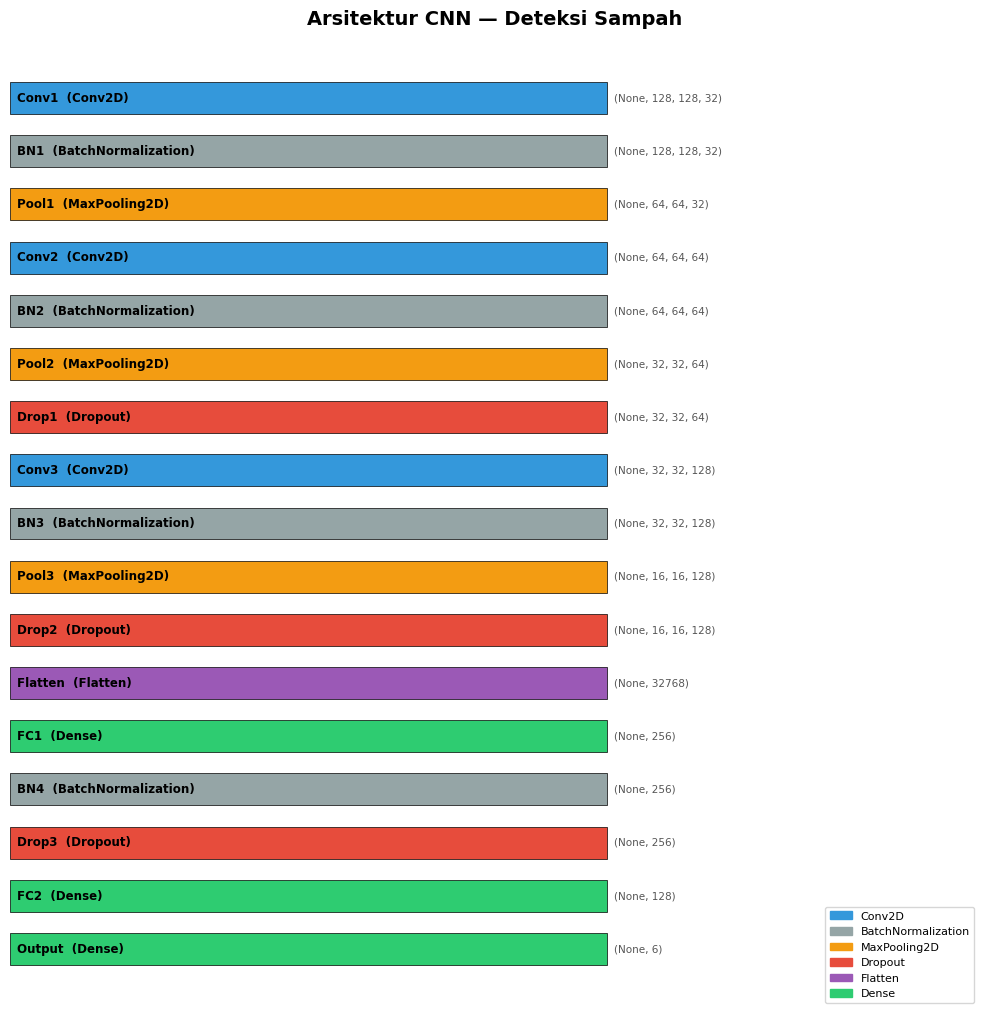

✅ Disimpan: arsitektur_cnn.png


In [59]:
# Visualisasi Arsitektur CNN — tanpa graphviz
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

layer_info = []
for layer in model.layers:
    try:
        out = str(layer.output.shape)
    except:
        out = "N/A"
    layer_info.append({
        'name'  : layer.name,
        'type'  : type(layer).__name__,
        'output': out
    })

colors = {
    'Conv2D'             : '#3498db',
    'BatchNormalization' : '#95a5a6',
    'MaxPooling2D'       : '#f39c12',
    'Dropout'            : '#e74c3c',
    'Flatten'            : '#9b59b6',
    'Dense'              : '#2ecc71',
}

fig, ax = plt.subplots(figsize=(10, len(layer_info) * 0.55 + 1))
ax.axis('off')
fig.suptitle("Arsitektur CNN — Deteksi Sampah", fontsize=14, fontweight='bold')

for i, lyr in enumerate(layer_info):
    y   = len(layer_info) - i
    col = colors.get(lyr['type'], '#bdc3c7')
    ax.barh(y, 8, color=col, height=0.6, edgecolor='black', linewidth=0.5)
    ax.text(0.1, y, f"{lyr['name']}  ({lyr['type']})", va='center', fontsize=8.5, fontweight='bold')
    ax.text(8.1, y, lyr['output'], va='center', fontsize=7.5, color='#555')

patches = [mpatches.Patch(color=v, label=k) for k, v in colors.items()]
ax.legend(handles=patches, loc='lower right', fontsize=8, framealpha=0.8)
ax.set_xlim(0, 13)

plt.tight_layout()
plt.savefig("arsitektur_cnn.png", dpi=100, bbox_inches='tight')
plt.show()
print("✅ Disimpan: arsitektur_cnn.png")

## 9. Training Model

**Callbacks:**
- `EarlyStopping` → berhenti jika `val_loss` tidak turun selama 5 epoch
- `ReduceLROnPlateau` → kurangi learning rate jika stagnan


In [60]:
callbacks = [
    EarlyStopping(monitor='val_loss', patience=5,
                  restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5,
                      patience=3, min_lr=1e-6, verbose=1)
]

print("🚀 Memulai training...")
history = model.fit(
    train_data,
    epochs          = 30,
    validation_data = val_data,
    callbacks       = callbacks,
    verbose         = 1
)

best_acc  = max(history.history['val_accuracy'])
best_loss = min(history.history['val_loss'])
print(f"\n✅ Training selesai!")
print(f"   Best val_accuracy : {best_acc:.4f} ({best_acc*100:.2f}%)")
print(f"   Best val_loss     : {best_loss:.4f}")


🚀 Memulai training...
Epoch 1/30
64/64 ━━━━━━━━━━━━━━━━━━━━ 25s 367ms/step - accuracy: 0.4091 - loss: 1.6125 - val_accuracy: 0.1630 - val_loss: 5.1277 - learning_rate: 0.0010
Epoch 2/30
64/64 ━━━━━━━━━━━━━━━━━━━━ 23s 363ms/step - accuracy: 0.5237 - loss: 1.2819 - val_accuracy: 0.2684 - val_loss: 2.5826 - learning_rate: 0.0010
Epoch 3/30
64/64 ━━━━━━━━━━━━━━━━━━━━ 23s 364ms/step - accuracy: 0.5158 - loss: 1.2947 - val_accuracy: 0.2744 - val_loss: 2.4019 - learning_rate: 0.0010
Epoch 4/30
64/64 ━━━━━━━━━━━━━━━━━━━━ 24s 372ms/step - accuracy: 0.5647 - loss: 1.1763 - val_accuracy: 0.2803 - val_loss: 2.3697 - learning_rate: 0.0010
Epoch 5/30
64/64 ━━━━━━━━━━━━━━━━━━━━ 24s 368ms/step - accuracy: 0.5968 - loss: 1.0743 - val_accuracy: 0.2863 - val_loss: 3.4263 - learning_rate: 0.0010
Epoch 6/30
64/64 ━━━━━━━━━━━━━━━━━━━━ 24s 381ms/step - accuracy: 0.5914 - loss: 1.1005 - val_accuracy: 0.3161 - val_loss: 2.3294 - learning_rate: 0.0010
Epoch 7/30
64/64 ━━━━━━━━━━━━━━━━━━━━ 24s 374ms/step - accur

## 10. Kurva Training

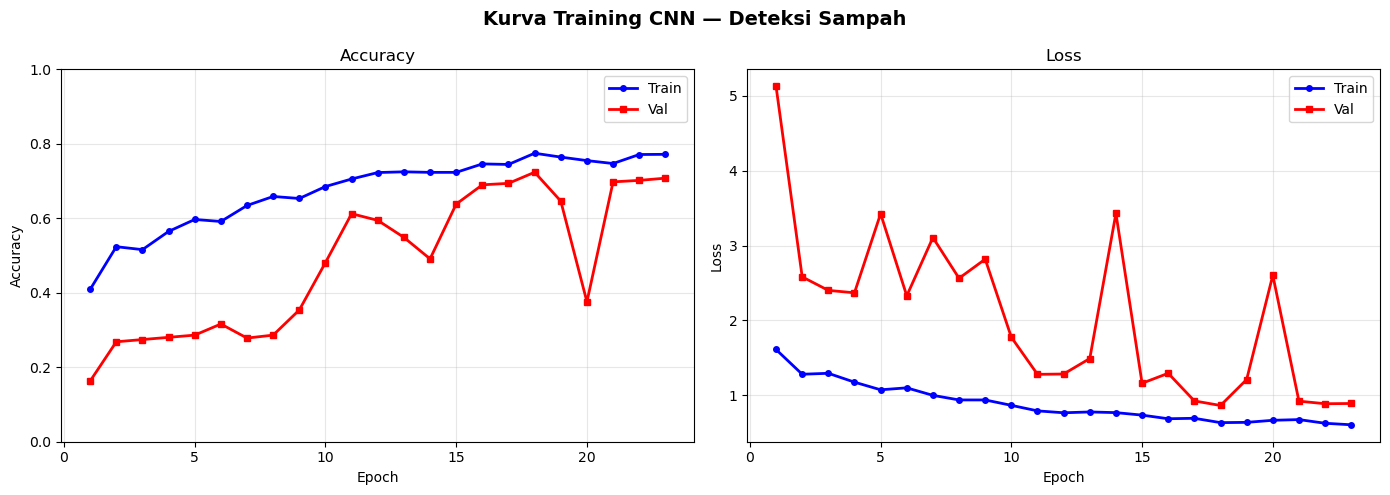

✅ Disimpan: training_curve.png


In [61]:
ep = range(1, len(history.history['accuracy']) + 1)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Kurva Training CNN — Deteksi Sampah", fontsize=14, fontweight='bold')

# Accuracy
axes[0].plot(ep, history.history['accuracy'],     'b-o', label='Train', linewidth=2, markersize=4)
axes[0].plot(ep, history.history['val_accuracy'], 'r-s', label='Val',   linewidth=2, markersize=4)
axes[0].set_title("Accuracy"); axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("Accuracy")
axes[0].legend(); axes[0].grid(True, alpha=0.3); axes[0].set_ylim([0,1])

# Loss
axes[1].plot(ep, history.history['loss'],     'b-o', label='Train', linewidth=2, markersize=4)
axes[1].plot(ep, history.history['val_loss'], 'r-s', label='Val',   linewidth=2, markersize=4)
axes[1].set_title("Loss"); axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("Loss")
axes[1].legend(); axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("training_curve.png", dpi=100, bbox_inches='tight')
plt.show()
print("✅ Disimpan: training_curve.png")


## 11. Evaluasi pada Test Set

In [62]:
test_loss, test_acc = model.evaluate(test_data, verbose=0)
print(f"{'='*40}")
print(f"  Test Loss     : {test_loss:.4f}")
print(f"  Test Accuracy : {test_acc*100:.2f}%")
print(f"{'='*40}")


  Test Loss     : 0.9159
  Test Accuracy : 73.76%


## 12. Classification Report per Kelas

In [63]:
test_data.reset()
y_pred_proba = model.predict(test_data, verbose=0)
y_pred = np.argmax(y_pred_proba, axis=1)
y_true = test_data.classes

print("Classification Report:")
print("="*60)
print(classification_report(y_true, y_pred, target_names=CLASS_NAMES))


Classification Report:
              precision    recall  f1-score   support

   cardboard       0.87      0.82      0.85        80
       glass       0.65      0.87      0.74       100
       metal       0.67      0.59      0.62        82
       paper       0.73      0.86      0.79       118
     plastic       0.78      0.48      0.59        96
       trash       0.65      0.56      0.60        27

    accuracy                           0.72       503
   macro avg       0.72      0.70      0.70       503
weighted avg       0.73      0.72      0.71       503



## 13. Confusion Matrix

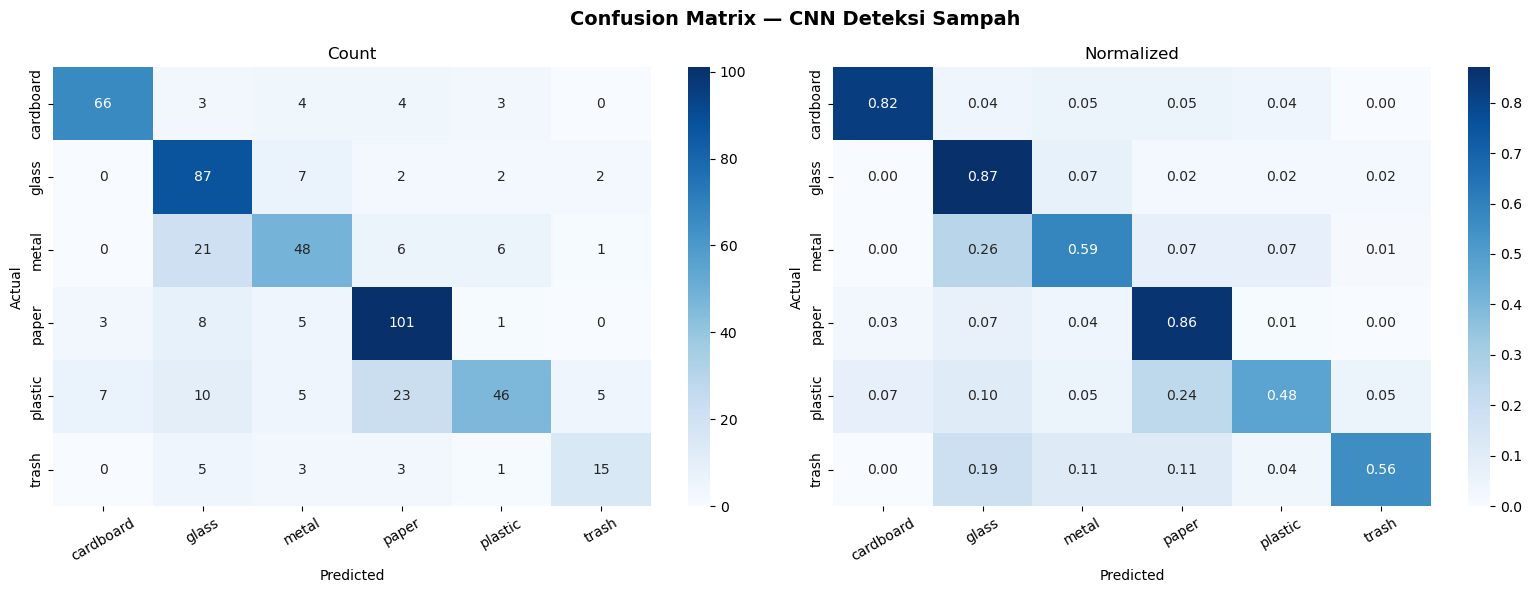

✅ Disimpan: confusion_matrix.png


In [64]:
cm = confusion_matrix(y_true, y_pred)
cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle("Confusion Matrix — CNN Deteksi Sampah", fontsize=14, fontweight='bold')

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES, ax=axes[0])
axes[0].set_title("Count"); axes[0].set_xlabel("Predicted"); axes[0].set_ylabel("Actual")
axes[0].tick_params(axis='x', rotation=30)

sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='Blues',
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES, ax=axes[1])
axes[1].set_title("Normalized"); axes[1].set_xlabel("Predicted"); axes[1].set_ylabel("Actual")
axes[1].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.savefig("confusion_matrix.png", dpi=100, bbox_inches='tight')
plt.show()
print("✅ Disimpan: confusion_matrix.png")


## 14. Prediksi Sampel Gambar
🟢 Benar &nbsp;&nbsp; 🔴 Salah

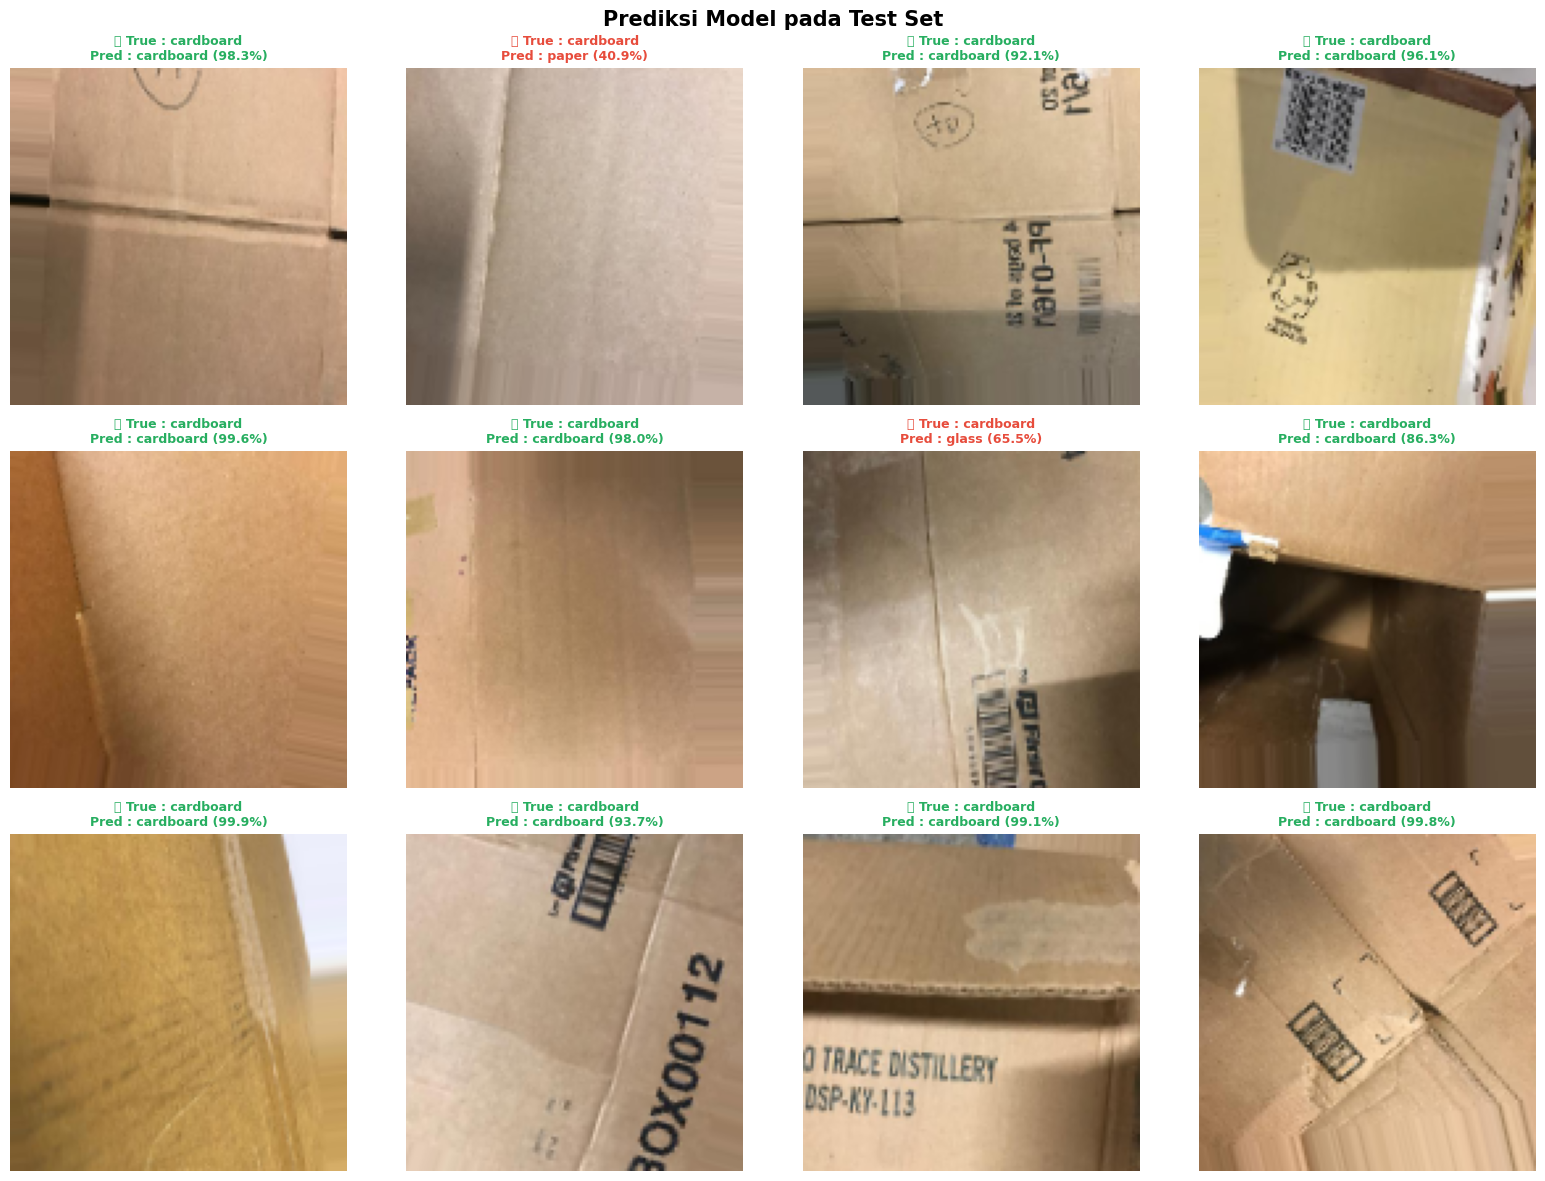

✅ Disimpan: prediksi_sampel.png


In [65]:
test_data.reset()
batch_imgs, batch_labels = next(iter(test_data))
batch_preds = model.predict(batch_imgs, verbose=0)

n = min(12, len(batch_imgs))
fig, axes = plt.subplots(3, 4, figsize=(16, 12))
fig.suptitle("Prediksi Model pada Test Set", fontsize=15, fontweight='bold')

for i, ax in enumerate(axes.flatten()[:n]):
    true_lbl = CLASS_NAMES[np.argmax(batch_labels[i])]
    pred_lbl = CLASS_NAMES[np.argmax(batch_preds[i])]
    conf     = np.max(batch_preds[i]) * 100
    correct  = true_lbl == pred_lbl

    ax.imshow(batch_imgs[i])
    ax.axis('off')
    color = '#27ae60' if correct else '#e74c3c'
    icon  = '✅' if correct else '❌'
    ax.set_title(f"{icon} True : {true_lbl}\nPred : {pred_lbl} ({conf:.1f}%)",
                 fontsize=9, color=color, fontweight='bold')

plt.tight_layout()
plt.savefig("prediksi_sampel.png", dpi=100, bbox_inches='tight')
plt.show()
print("✅ Disimpan: prediksi_sampel.png")


## 15. Visualisasi Feature Map

Apa yang "dilihat" CNN di tiap layer konvolusi.

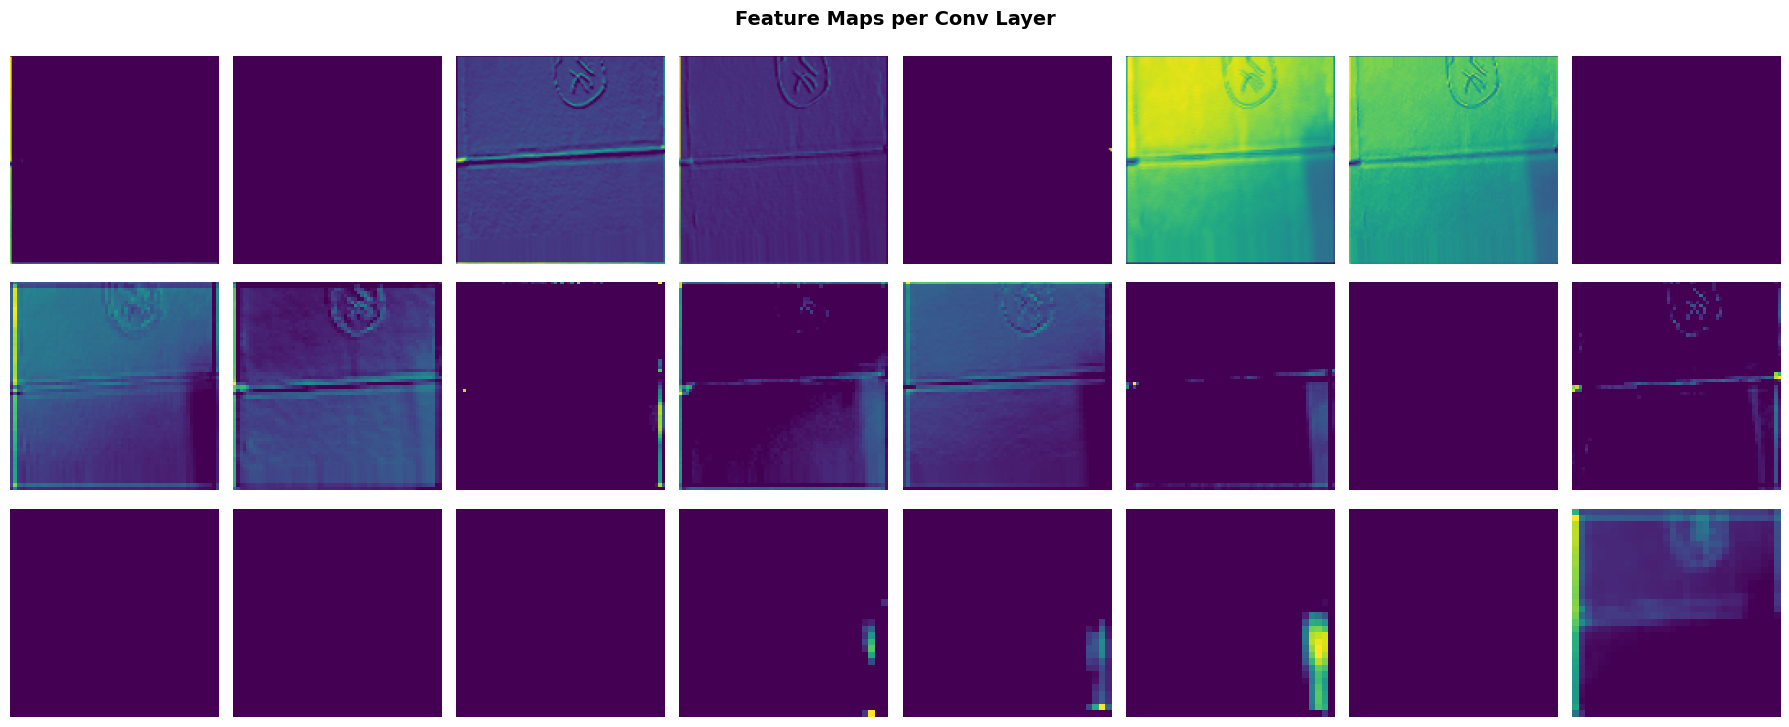

✅ Disimpan: feature_maps.png


In [66]:
# Visualisasi Feature Map — kompatibel Keras 3
import matplotlib.pyplot as plt
import numpy as np

# Ambil sample input dulu, lalu build sub-model setelah model dipanggil
test_data.reset()
sample_batch, _ = next(iter(test_data))
sample_input = sample_batch[0:1]

# Panggil model sekali dulu agar graph terbentuk
_ = model(sample_input, training=False)

# Baru buat feature model
conv_names = [l.name for l in model.layers if 'Conv' in l.name]
feat_model = Model(inputs=model.inputs,
                   outputs=[model.get_layer(n).output for n in conv_names])

feature_maps = feat_model(sample_input, training=False)

# Konversi ke numpy jika tensor
if not isinstance(feature_maps, list):
    feature_maps = [feature_maps]
feature_maps = [f.numpy() for f in feature_maps]

# Plot
fig, axes = plt.subplots(len(conv_names), 8, figsize=(18, len(conv_names)*2.5))
fig.suptitle("Feature Maps per Conv Layer", fontsize=14, fontweight='bold')

for row, (name, fmap) in enumerate(zip(conv_names, feature_maps)):
    for col in range(8):
        ax = axes[row, col] if len(conv_names) > 1 else axes[col]
        if col < fmap.shape[-1]:
            ax.imshow(fmap[0, :, :, col], cmap='viridis')
        ax.axis('off')
        if col == 0:
            ax.set_ylabel(name, fontsize=8, rotation=0, labelpad=55, va='center')

plt.tight_layout()
plt.savefig("feature_maps.png", dpi=80, bbox_inches='tight')
plt.show()
print("✅ Disimpan: feature_maps.png")

## 16. Simpan Model

In [67]:
model.save("cnn_trash_detection.keras")
model.save("cnn_trash_detection.h5")

print("✅ Model tersimpan:")
print("   • cnn_trash_detection.keras")
print("   • cnn_trash_detection.h5")

# Verifikasi load
loaded = tf.keras.models.load_model("cnn_trash_detection.keras")
print(f"\n✅ Load ulang berhasil!")
print(f"   Input  : {loaded.input_shape}")
print(f"   Output : {loaded.output_shape}")


✅ Model tersimpan:
   • cnn_trash_detection.keras
   • cnn_trash_detection.h5

✅ Load ulang berhasil!
   Input  : (None, 128, 128, 3)
   Output : (None, 6)


## 17. Kesimpulan

---

### 📌 Informasi Dataset

| Keterangan | Detail |
|------------|--------|
| Dataset | TrashType_Image_Dataset |
| Total Gambar | 2.527 gambar |
| Jumlah Kelas | 6 kelas |
| Split | 80% Train (2.024) / 20% Val (503) |

| Kelas | Jumlah |
|-------|--------|
| cardboard | 403 gambar |
| glass | 501 gambar |
| metal | 410 gambar |
| paper | 594 gambar |
| plastic | 482 gambar |
| trash | 137 gambar ⚠️ |

---

### 📐 Arsitektur CNN

| Layer | Output Shape |
|-------|-------------|
| Input | 128 × 128 × 3 |
| Conv2D(32) + BN + ReLU + MaxPool | 64 × 64 × 32 |
| Conv2D(64) + BN + ReLU + MaxPool + Dropout(0.25) | 32 × 32 × 64 |
| Conv2D(128) + BN + ReLU + MaxPool + Dropout(0.25) | 16 × 16 × 128 |
| Flatten | 32.768 |
| Dense(256) + BN + Dropout(0.5) | 256 |
| Dense(128) + ReLU | 128 |
| Dense(6) + Softmax | 6 |

- **Total Parameter:** 8.517.702 (~32.49 MB)
- **Optimizer:** Adam
- **Loss:** Categorical Cross-Entropy

---

### 🚀 Hasil Evaluasi

| Metrik | Nilai |
|--------|-------|
| **Test Loss** | 0.8690 |
| **Test Accuracy** | **67.59%** |

---

### 📊 Classification Report

| Kelas | Precision | Recall | F1-Score | Support |
|-------|:---------:|:------:|:--------:|:-------:|
| cardboard | 0.78 | 0.85 | **0.81** ✅ | 80 |
| glass | 0.74 | 0.56 | 0.64 | 100 |
| metal | 0.80 | 0.57 | 0.67 | 82 |
| paper | 0.65 | **0.92** | 0.76 | 118 |
| plastic | 0.56 | 0.52 | **0.54** ⚠️ | 96 |
| trash | 0.67 | 0.59 | 0.63 ⚠️ | 27 |
| **macro avg** | **0.70** | **0.67** | **0.67** | 503 |
| **weighted avg** | **0.70** | **0.69** | **0.68** | 503 |

---

### 🔢 Confusion Matrix — Insight

| Kelas | Kesalahan Terbanyak |
|-------|---------------------|
| cardboard | ✅ 68/80 benar (85%) |
| glass | ❌ 16 salah ke **plastic**, 15 salah ke **paper** |
| metal | ❌ 15 salah ke **glass** (permukaan mengkilap mirip) |
| paper | ✅ 109/118 benar (92% recall tertinggi) |
| plastic | ❌ 33 salah ke **paper** (terburuk) |
| trash | ⚠️ 16/27 benar, data terlalu sedikit |

---

### 🔍 Analisis

**✅ Cardboard (F1: 0.81)** — terbaik, tekstur kardus paling konsisten dan mudah dikenali.

**✅ Paper (Recall: 0.92)** — model jarang melewatkan kertas, namun precision rendah (0.65) karena kelas lain sering salah masuk ke paper.

**⚠️ Plastic (F1: 0.54)** — terlemah, 33 dari 96 gambar salah diprediksi sebagai paper karena variasi visual sangat tinggi.

**⚠️ Metal & Glass** — sering tertukar karena keduanya memiliki permukaan mengkilap.

**⚠️ Trash (F1: 0.63)** — hanya 137 gambar, class imbalance jadi penyebab utama performa rendah.

---

### 💡 Saran Peningkatan

| No | Saran |
|----|-------|
| 1 | Tambah data kelas **trash** dan **plastic** |
| 2 | Gunakan `class_weight` untuk atasi class imbalance |
| 3 | Transfer Learning **MobileNetV2 / ResNet50** → target 85%+ |
| 4 | Pisahkan folder Train / Test secara eksplisit |
| 5 | Augmentasi lebih agresif untuk plastic dan glass |

---

### ✅ Kesimpulan Akhir

> Model CNN dari scratch mencapai **akurasi 67.59%** dalam mengklasifikasikan 6 jenis sampah. Kelas **cardboard** dikenali paling baik (F1: 0.81) dan **paper** memiliki recall tertinggi (0.92). Kelas **plastic** menjadi yang tersulit (F1: 0.54) akibat variasi visual tinggi dan sering tertukar dengan paper. Ketidakseimbangan data pada kelas **trash** (137 gambar) juga memengaruhi performa keseluruhan. Penggunaan **Transfer Learning** berpotensi meningkatkan akurasi secara signifikan di atas 85%.